# Classifying a Topological (SPT) Phase with a Quantum Extreme Learning Machine

*A standalone worked example.* We take the ground state of a many-body chain that
hosts a **symmetry-protected topological (SPT)** phase, push it once through a fixed
quantum "reservoir", read out a handful of low-weight Pauli expectation values, and
train **only** a linear classifier on top. The twist that makes this example sharper
than its symmetry-breaking cousin: the SPT phase has **no local order parameter**, so
a linear readout on the *bare* observables is at chance. After a fixed scramble, the
*same* readout separates the phases and its decision boundary lands near the true
critical point. Scrambling is what makes the topological order locally measurable.

## Motivation: order without a local order parameter

A conventional (Landau) phase transition is signalled by a **local order parameter**:
an observable that is nonzero in one phase and vanishes in the other, tied to a broken
symmetry. A **symmetry-protected topological (SPT)** phase breaks *no* symmetry. Its
two phases cannot be told apart by any local order parameter at all; the distinction
lives in a **nonlocal string** and in the entanglement structure.

The **cluster-Ising** chain is the cleanest example. In the SPT (cluster) phase the
ground state is a cluster state, whose order is stored in a string operator spanning
the whole chain. Every conventional local order parameter, the magnetizations and the
short-range correlators, is **identically zero in both phases**. This is exactly the
obstruction the chapter is about: the phase information is present in the state but
invisible to local measurements.

A **Quantum Extreme Learning Machine (QELM)** turns the obstruction into a tool:

1. The **input is a quantum state**, the ground state $|\psi_{\rm gs}(h)\rangle$.
2. A **fixed, untrained** scrambling unitary spreads its information across the register.
3. We measure a **fixed** bank of simple, low-weight observables to form a feature vector.
4. Only a **classical linear readout** is trained.

Under the scramble a low-weight observable $O$ becomes the high-weight $U^\dagger O U$,
which overlaps the nonlocal string order. So the fixed, generic scramble rotates the
hidden topological order into ordinary low-weight expectation values, and a linear
readout on them succeeds where the bare readout could not.

## Problem statement

**Model.** The cluster-Ising chain on an open chain of $N$ spins,
$$
H(h) = -J\sum_{i} Z_{i-1} X_i Z_{i+1} \;-\; h \sum_i X_i .
$$
It has a quantum phase transition at $h/J = 1$:

- $h < 1$: **SPT / cluster** phase (the three-body cluster term dominates).
- $h > 1$: **trivial paramagnet** (the transverse field dominates).

**Protecting symmetry.** $H(h)$ commutes with the two sublattice parities
$P_{\rm even} = \prod_{i\ {\rm even}} X_i$ and $P_{\rm odd} = \prod_{i\ {\rm odd}} X_i$,
generating a $\mathbb{Z}_2 \times \mathbb{Z}_2$ symmetry that protects the SPT phase.

**Task.** Given only the ground state at a field $h$, decide which phase it is in,
training only far from criticality and never using an order parameter.

**QELM protocol (per input $h$).**
1. Diagonalize $H(h)$ (in the symmetry sector) and take the ground state.
2. Evolve under a **fixed** nonintegrable scrambling unitary $U = e^{-i H_{\rm res} t}$.
3. Read a fixed bank of low-weight Pauli expectations
   $f_\alpha = \langle \psi_{\rm gs}| U^\dagger O_\alpha U |\psi_{\rm gs}\rangle$.
4. Fit a linear (logistic) readout on $f$ to predict the phase label.

In [1]:
import numpy as np
from scipy.linalg import expm, eigh
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

def kron_op(single, site, N):
    op = np.array([[1.0]], dtype=complex)
    for j in range(N):
        op = np.kron(op, single if j == site else I2)
    return op

def kron_string(ops_by_site, N):
    op = np.array([[1.0]], dtype=complex)
    for j in range(N):
        op = np.kron(op, ops_by_site.get(j, I2))
    return op

### The model Hamiltonian, its symmetry, and a unique ground state

We build $H(h)$ densely (for $N=8$ the Hilbert space is only $2^8 = 256$ dimensional).
Two subtleties make the SPT chain different from the transverse-field Ising case.

**Edge modes.** On an *open* chain the cluster term only runs over the $N-2$ interior
sites, so the pure cluster Hamiltonian has a four-fold degenerate ground space (the
hallmark of the SPT phase: protected edge modes). A bare diagonalizer would return an
arbitrary mixture inside this near-degenerate space, washing out the string order. We
remove the ambiguity by **projecting onto the $(P_{\rm even}, P_{\rm odd}) = (+1,+1)$
symmetry sector** (the sector that also contains the trivial all-$|+\rangle$ state),
which selects one unique, symmetric ground state.

**No local order parameter.** In the symmetric ground state the single-site
magnetizations $\langle Z_i\rangle, \langle Y_i\rangle$ and the nearest-neighbour
correlators $\langle Z_iZ_{i+1}\rangle, \langle Y_iY_{i+1}\rangle$ are **zero in both
phases**, forbidden by the protecting symmetry. We verify this below.

In [2]:
def cluster_ising(N, J, h):
    # H(h) = -J sum Z_{i-1} X_i Z_{i+1} - h sum X_i on an open chain
    H = np.zeros((2**N, 2**N), dtype=complex)
    for i in range(1, N - 1):
        H += -J * (kron_op(Z, i - 1, N) @ kron_op(X, i, N) @ kron_op(Z, i + 1, N))
    for i in range(N):
        H += -h * kron_op(X, i, N)
    return H

def sublattice_parity(N):
    Pe = np.eye(2**N, dtype=complex); Po = np.eye(2**N, dtype=complex)
    for s in range(N):
        if s % 2 == 0: Pe = Pe @ kron_op(X, s, N)
        else:          Po = Po @ kron_op(X, s, N)
    return Pe, Po

def symmetry_projector(N):
    Pe, Po = sublattice_parity(N)
    return ((np.eye(2**N) + Pe) / 2) @ ((np.eye(2**N) + Po) / 2)

def ground_state(N, J, h, Proj, lam=50.0):
    # lift every other symmetry sector by lam; the (+1,+1) sector is untouched
    w, v = eigh(cluster_ising(N, J, h) + lam * (np.eye(2**N) - Proj))
    return v[:, 0].astype(complex)

N, J = 8, 1.0
Proj = symmetry_projector(N)

# Verify: the conventional local order parameters vanish in BOTH phases.
for h in (0.2, 1.8):
    psi = ground_state(N, J, h, Proj)
    z0 = np.vdot(psi, kron_op(Z, N//2, N) @ psi).real
    zz = np.vdot(psi, (kron_op(Z, N//2, N) @ kron_op(Z, N//2+1, N)) @ psi).real
    print(f"h={h}:  <Z_i>={z0:+.2e}   <Z_i Z_i+1>={zz:+.2e}   (both ~0, symmetry-forbidden)")

h=0.2:  <Z_i>=-1.91e-16   <Z_i Z_i+1>=+2.08e-17   (both ~0, symmetry-forbidden)


h=1.8:  <Z_i>=-9.71e-17   <Z_i Z_i+1>=-1.67e-16   (both ~0, symmetry-forbidden)


### The nonlocal string order parameter

The order that *does* distinguish the phases is the product of the bulk cluster
stabilizers $K_i = Z_{i-1} X_i Z_{i+1}$. Multiplying them along the chain telescopes the
$Z$'s and leaves
$$
S = \big\langle\, Z_1\, Y_2\, X_3 \cdots X_{N-2}\, Y_{N-1}\, Z_N \,\big\rangle ,
$$
a **weight-$N$** string: $Z$ on the two ends, $Y$ just inside, $X$ across the bulk. (The
field-along-$X$ convention puts $Y$'s next to the $Z$ endpoints; a naive $Z\!\cdots\!Z$
string is identically zero here.) $S \approx 1$ on the ideal cluster state and decays to
$0$ in the trivial phase. Crucially $S$ is **nonlocal**: it is in no low-weight bank and
cannot be read from local measurements on the bare state.

In [3]:
def string_operator(N):
    ops = {0: Z, N-1: Z, 1: Y, N-2: Y}
    for j in range(2, N-2):
        ops[j] = X
    return kron_string(ops, N)

Sop = string_operator(N)
for h in (0.05, 0.5, 2.0):
    psi = ground_state(N, J, h, Proj)
    print(f"h={h}:  string order S = {np.vdot(psi, Sop @ psi).real:+.3f}")

h=0.05:  string order S = +0.995


h=0.5:  string order S = +0.487


h=2.0:  string order S = +0.001


### The fixed reservoir: a symmetry-breaking scrambler

For the input to be usefully re-expressed in low-weight observables the reservoir must
**scramble**. A pure transverse-field Ising model is Jordan-Wigner integrable and does
not scramble; adding a **longitudinal** field breaks integrability. A second requirement
appears here: the reservoir must also **break the protecting
$\mathbb{Z}_2\times\mathbb{Z}_2$ symmetry**. If it did not, $U^\dagger O U$ would stay in
the symmetry-forbidden sector and its expectation would remain exactly zero, no matter
how strongly the reservoir mixed the state.

The mixed-field Ising chain
$H_{\rm res} = J_r \sum_i Z_i Z_{i+1} + h_x \sum_i X_i + h_z \sum_i Z_i$ does both: the
longitudinal $h_z$ breaks integrability *and* the cluster symmetry. We fix its
parameters and the evolution time once; nothing in the reservoir is trained.

In [4]:
def mixed_field_ising(N, Jr, hx, hz):
    H = np.zeros((2**N, 2**N), dtype=complex)
    for i in range(N - 1):
        H += Jr * (kron_op(Z, i, N) @ kron_op(Z, i + 1, N))
    for i in range(N):
        H += hx * kron_op(X, i, N) + hz * kron_op(Z, i, N)
    return H

JR, HX, HZ, T_EV = 1.0, 1.05, 0.5, 2.5
U = expm(-1j * mixed_field_ising(N, JR, HX, HZ) * T_EV)   # fixed once

Pe, Po = sublattice_parity(N)
Hres = mixed_field_ising(N, JR, HX, HZ)
print("U unitary?", np.allclose(U.conj().T @ U, np.eye(2**N)))
print("reservoir breaks the cluster symmetry?", not np.allclose(Hres @ Pe, Pe @ Hres))

U unitary? True
reservoir breaks the cluster symmetry? True


### The fixed measurement bank: symmetry-forbidden local observables

We read a bank of **low-weight** observables that are exactly the conventional local
order-parameter candidates: single-site $\{Y_i, Z_i\}$ and nearest-neighbour
$\{Y_iY_{i+1}, Z_iZ_{i+1}\}$. Every one of them is **forbidden by the protecting
symmetry**, so on the bare ground state it vanishes in both phases. For a pure state
$\psi$, a Pauli string $P = i^{p} X^{x} Z^{z}$ has
$\langle P\rangle = \mathrm{Re}\sum_b \overline{\psi_b}\, W_b\, \psi_{b\oplus x}$,
an $O(2^N)$ contraction we vectorize over the whole bank at once.

In [5]:
_POP = np.array([bin(i).count('1') for i in range(1 << 16)])
_PH = np.array([1, 1j, -1, -1j])

def pauli_readout(N):
    bit = lambda i: 1 << (N - 1 - i)
    specs, names = [], []
    for i in range(N):
        specs += [(bit(i), bit(i), 1), (0, bit(i), 0)]        # Y_i, Z_i
        names += [f'Y{i}', f'Z{i}']
    for i in range(N - 1):
        m = bit(i) | bit(i + 1)
        specs += [(m, m, 2), (0, m, 0)]                       # Y_iY_{i+1}, Z_iZ_{i+1}
        names += [f'Y{i}Y{i+1}', f'Z{i}Z{i+1}']
    b = np.arange(1 << N)
    COLS = np.array([b ^ x for (x, z, p) in specs])
    W = np.array([_PH[p] * (1 - 2 * (_POP[z & b] & 1)) for (x, z, p) in specs],
                 dtype=complex)
    return COLS, W, names

COLS, W, names = pauli_readout(N)
print(f"{len(names)} symmetry-forbidden features, e.g. {names[:2]} ... {names[-2:]}")

30 symmetry-forbidden features, e.g. ['Y0', 'Z0'] ... ['Y6Y7', 'Z6Z7']


### The feature map, and why the bare readout is blind

For each input $h$ we form the symmetric ground state and read the bank either on the
**bare** state or on the **scrambled** state $\phi = U\psi$. The bare features vanish to
machine precision; the scrambled features are $O(0.1)$ and carry the string order.

In [6]:
def qelm_features(psi_list, U, COLS, W):
    F = np.zeros((len(psi_list), COLS.shape[0]))
    for n, psi in enumerate(psi_list):
        phi = U @ psi if U is not None else psi
        F[n] = np.real(np.conj(phi) * W * phi[COLS]).sum(axis=1)
    return F

psi_demo = ground_state(N, J, 0.2, Proj)
f_bare = qelm_features([psi_demo], None, COLS, W)
f_scram = qelm_features([psi_demo], U, COLS, W)
print("deep-SPT input h=0.2:")
print(f"  |bare features|   max = {np.abs(f_bare).max():.1e}   (zero: symmetry-forbidden)")
print(f"  |scrambled feat.| max = {np.abs(f_scram).max():.3f}   (nonzero: carries the string order)")

deep-SPT input h=0.2:
  |bare features|   max = 5.0e-16   (zero: symmetry-forbidden)
  |scrambled feat.| max = 0.152   (nonzero: carries the string order)


### Train far from criticality, test across the transition

We draw training fields **only** from the clearly-SPT ($h \in [0.05, 0.55]$) and
clearly-trivial ($h \in [1.45, 2.5]$) windows, label them $0/1$, hold out a separate set
of clear-region fields for honest accuracy, and use a dense sweep to probe the critical
region the readout never trained on.

In [7]:
H_TR_SPT = np.linspace(0.05, 0.55, 10); H_TR_TRIV = np.linspace(1.45, 2.50, 10)
H_TE_SPT = np.linspace(0.10, 0.50, 8); H_TE_TRIV = np.linspace(1.50, 2.45, 8)
H_SWEEP = np.linspace(0.02, 2.5, 120)

def states(hs): return [ground_state(N, J, h, Proj) for h in hs]

h_train = np.r_[H_TR_SPT, H_TR_TRIV]; y_train = np.r_[np.zeros(10), np.ones(10)]
h_test = np.r_[H_TE_SPT, H_TE_TRIV]; y_test = np.r_[np.zeros(8), np.ones(8)]

psi_train, psi_test, psi_sweep = states(h_train), states(h_test), states(H_SWEEP)
F_train = qelm_features(psi_train, U, COLS, W)   # scrambled
F_test = qelm_features(psi_test, U, COLS, W)
F_sweep = qelm_features(psi_sweep, U, COLS, W)
B_train = qelm_features(psi_train, None, COLS, W) # bare (~0)
B_test = qelm_features(psi_test, None, COLS, W)
print("scrambled features:", F_train.shape, " |bare|max =", f"{np.abs(B_train).max():.1e}")

scrambled features: (20, 30)  |bare|max = 6.7e-16


### Train the linear readout on the scrambled features

The only trainable object is a logistic-regression readout on the standardized
*scrambled* features. Because each feature $f_\alpha = \mathrm{Tr}(\rho\,U^\dagger
O_\alpha U)$ is **linear in the state** $\rho$, a linear readout is the well-posed
choice.

In [8]:
scaler = StandardScaler().fit(F_train)
clf = LogisticRegression(C=1.0, max_iter=5000).fit(scaler.transform(F_train), y_train)

acc_test = clf.score(scaler.transform(F_test), y_test)
prob_sweep = clf.predict_proba(scaler.transform(F_sweep))[:, 1]  # P(trivial)

cross = np.where(np.diff(np.sign(prob_sweep - 0.5)) != 0)[0][0]
p0, p1 = prob_sweep[cross], prob_sweep[cross + 1]
h_cross = H_SWEEP[cross] + (0.5 - p0) / (p1 - p0) * (H_SWEEP[cross + 1] - H_SWEEP[cross])

print(f"held-out accuracy = {acc_test:.3f}")
print(f"decision crossing = {h_cross:.3f}   (true h_c = 1; finite size shifts it below 1)")

held-out accuracy = 1.000
decision crossing = 0.813   (true h_c = 1; finite size shifts it below 1)


### The ablation: bare vs scrambled, under finite shots

A real device estimates each expectation from a finite number of measurement shots, with
variance $(1-\langle O\rangle^2)/M$. On the **bare** forbidden features (true value zero)
this is pure noise, so the readout is at chance no matter how many shots are taken. On
the **scrambled** features the $O(0.1)$ signal survives easily. We average the accuracy
over shot-noise realizations for a fair, identical comparison.

In [9]:
def add_shot_noise(F, shots, rng):
    var = np.clip(1.0 - F**2, 0, 1) / shots
    return F + rng.normal(size=F.shape) * np.sqrt(var)

def noisy_acc(Ftr, Fte, shots=1024, reals=60):
    rng = np.random.default_rng(0); a = []
    for _ in range(reals):
        Ftr_n, Fte_n = add_shot_noise(Ftr, shots, rng), add_shot_noise(Fte, shots, rng)
        sc = StandardScaler().fit(Ftr_n)
        c = LogisticRegression(C=1.0, max_iter=5000).fit(sc.transform(Ftr_n), y_train)
        a.append(c.score(sc.transform(Fte_n), y_test))
    return np.mean(a), np.std(a)

acc_bare, sd_bare = noisy_acc(B_train, B_test)
acc_scram, sd_scram = noisy_acc(F_train, F_test)
print(f"BARE  readout accuracy = {acc_bare:.3f} +/- {sd_bare:.3f}   (chance)")
print(f"SCRAM readout accuracy = {acc_scram:.3f} +/- {sd_scram:.3f}")

BARE  readout accuracy = 0.519 +/- 0.125   (chance)
SCRAM readout accuracy = 1.000 +/- 0.000


### Visualize: manifold, decision boundary, and the physics behind the ablation

Panel (a): a 2D PCA of the scrambled feature vectors, a smooth arc parametrized by $h$,
with the SPT and trivial training states apart. Panel (b): the readout's predicted
trivial probability, crossing near $h_c$. Panel (c): the nonlocal string order $S(h)$
dropping across $h_c$ while the local order parameter stays at zero, plus the
bare-vs-scrambled accuracies.

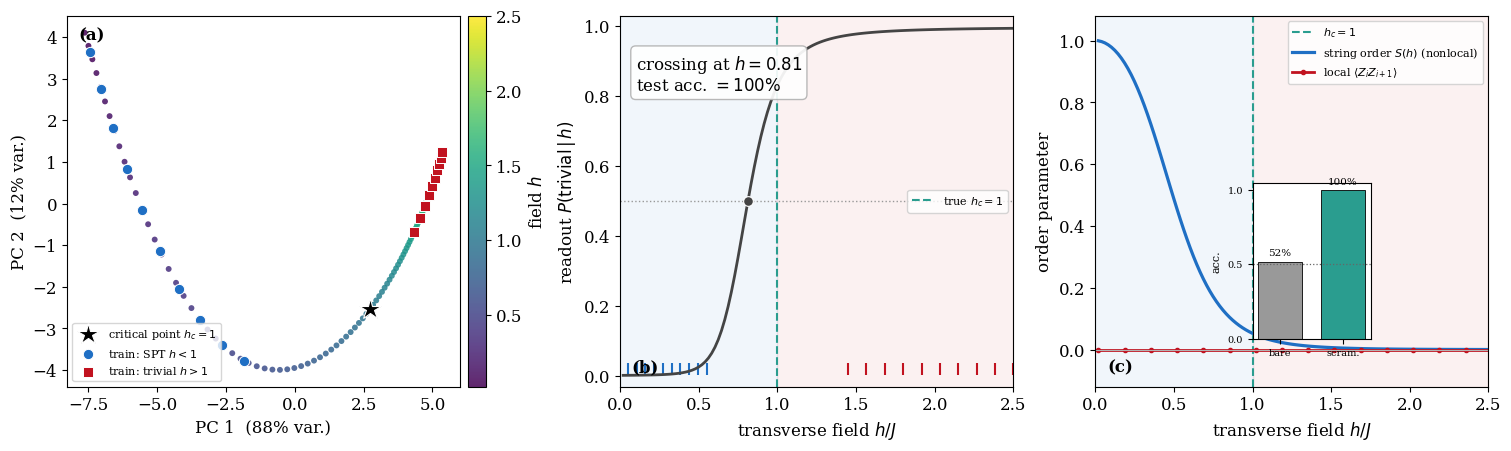

In [10]:
S_sweep = np.array([np.vdot(p, Sop @ p).real for p in psi_sweep])
ZZ_loc = kron_op(Z, N//2, N) @ kron_op(Z, N//2+1, N)
ZZ_sweep = np.array([np.vdot(p, ZZ_loc @ p).real for p in psi_sweep])

pca = PCA(n_components=2).fit(scaler.transform(F_train))
P_train = pca.transform(scaler.transform(F_train))
P_sweep = pca.transform(scaler.transform(F_sweep))
evr = pca.explained_variance_ratio_

C_SPT, C_TRIV, C_SWEEP, C_GC = '#1f6fc4', '#c1121f', '#444444', '#2a9d8f'
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, (axa, axb, axc) = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)
spt_m = y_train < 0.5

sc = axa.scatter(P_sweep[:, 0], P_sweep[:, 1], c=H_SWEEP, cmap='viridis',
                 s=18, alpha=0.85, edgecolors='none')
i_c = int(np.argmin(np.abs(H_SWEEP - 1.0)))
axa.plot(P_sweep[i_c, 0], P_sweep[i_c, 1], '*', color='black', ms=16, mec='white',
         mew=0.8, label=r'critical point $h_c=1$')
axa.scatter(P_train[spt_m, 0], P_train[spt_m, 1], s=55, color=C_SPT, marker='o',
            edgecolors='white', linewidths=0.7, label=r'train: SPT $h<1$')
axa.scatter(P_train[~spt_m, 0], P_train[~spt_m, 1], s=55, color=C_TRIV, marker='s',
            edgecolors='white', linewidths=0.7, label=r'train: trivial $h>1$')
axa.set_xlabel(f'PC 1  ({100*evr[0]:.0f}% var.)')
axa.set_ylabel(f'PC 2  ({100*evr[1]:.0f}% var.)')
fig.colorbar(sc, ax=axa, pad=0.02).set_label('field $h$')
axa.legend(loc='lower left', fontsize=8)
axa.text(0.03, 0.97, '(a)', transform=axa.transAxes, fontweight='bold', va='top')

axb.axvspan(0, 1, color=C_SPT, alpha=0.06); axb.axvspan(1, 2.5, color=C_TRIV, alpha=0.06)
axb.axhline(0.5, color='0.6', ls=':', lw=1.0)
axb.axvline(1.0, color=C_GC, ls='--', lw=1.5, label='true $h_c=1$')
axb.plot(H_SWEEP, prob_sweep, color=C_SWEEP, lw=2.0)
axb.plot([h_cross], [0.5], 'o', color=C_SWEEP, ms=7, mec='white', mew=0.8)
axb.scatter(h_train[spt_m], np.full(spt_m.sum(), 0.02), marker='|', s=70, color=C_SPT)
axb.scatter(h_train[~spt_m], np.full((~spt_m).sum(), 0.02), marker='|', s=70, color=C_TRIV)
axb.set_xlabel('transverse field $h/J$'); axb.set_ylabel(r'readout $P(\mathrm{trivial}\,|\,h)$')
axb.set_xlim(0, 2.5); axb.set_ylim(-0.03, 1.03)
axb.text(0.04, 0.90, f'crossing at $h={h_cross:.2f}$\ntest acc. $={acc_test*100:.0f}\\%$',
         transform=axb.transAxes, va='top',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.7', alpha=0.92))
axb.legend(loc='center right', fontsize=8)
axb.text(0.03, 0.03, '(b)', transform=axb.transAxes, fontweight='bold', va='bottom')

axc.axvspan(0, 1, color=C_SPT, alpha=0.06); axc.axvspan(1, 2.5, color=C_TRIV, alpha=0.06)
axc.axvline(1.0, color=C_GC, ls='--', lw=1.5, label='$h_c=1$')
axc.plot(H_SWEEP, S_sweep, color=C_SPT, lw=2.3, label='string order $S(h)$ (nonlocal)')
axc.plot(H_SWEEP, ZZ_sweep, color=C_TRIV, lw=2.0, marker='o', ms=3, markevery=8,
         label=r'local $\langle Z_iZ_{i+1}\rangle$')
axc.axhline(0.0, color='0.7', lw=0.8)
axc.set_xlabel('transverse field $h/J$'); axc.set_ylabel('order parameter')
axc.set_xlim(0, 2.5); axc.set_ylim(-0.12, 1.08); axc.legend(loc='upper right', fontsize=8)
axin = axc.inset_axes([0.40, 0.13, 0.30, 0.42])
axin.bar([0], [acc_bare], color='0.6', edgecolor='black', linewidth=0.6, width=0.7)
axin.bar([1], [acc_scram], color=C_GC, edgecolor='black', linewidth=0.6, width=0.7)
axin.axhline(0.5, color='0.4', ls=':', lw=0.9)
axin.set_xticks([0, 1]); axin.set_xticklabels(['bare', 'scram.'], fontsize=7.5)
axin.set_ylim(0, 1.05); axin.set_yticks([0, 0.5, 1]); axin.tick_params(labelsize=7)
axin.set_ylabel('acc.', fontsize=8)
axin.text(0, acc_bare + 0.04, f'{acc_bare*100:.0f}%', ha='center', fontsize=7.5)
axin.text(1, acc_scram + 0.04, f'{acc_scram*100:.0f}%', ha='center', fontsize=7.5)
axc.text(0.03, 0.03, '(c)', transform=axc.transAxes, fontweight='bold', va='bottom')
plt.show()

## Discussion

**What happened.** A fixed, untrained scramble turned each ground state into a feature
vector of ordinary low-weight expectation values. A linear readout, trained only on
states far from the transition, learned the boundary between the SPT and trivial phases
and placed it near the true critical point $h_c = 1$, without ever being handed an order
parameter.

**Why the bare readout fails.** The SPT phase breaks no symmetry, so every low-weight
observable in our bank is forbidden by the protecting $\mathbb{Z}_2\times\mathbb{Z}_2$
symmetry and vanishes identically in both phases. The phase information lives only in the
nonlocal weight-$N$ string order $S$. A linear readout on the bare features has no
signal, and under finite shots it sits at chance.

**Why scrambling fixes it.** Under $U$ a low-weight $O$ becomes the high-weight
$U^\dagger O U$. Because the reservoir does **not** share the protecting symmetry, this
scrambled observable is no longer forced to vanish, and it overlaps the string order. The
same low-weight readout, now on the scrambled features, inherits the topological order
and separates the phases. This is the chapter's thesis made concrete: scrambling turns
the obstruction (nonlocality) into the tool (local measurability).

**A sharper statement.** It is specifically the reservoir's **symmetry breaking**, not
scrambling alone, that unlocks the order. A symmetry-*respecting* scrambler, however
strong, keeps $U^\dagger O U$ in the forbidden sector, so the scrambled features stay
exactly zero and the readout stays at chance. The reader can verify this by replacing
$H_{\rm res}$ with a cluster-plus-transverse Hamiltonian that commutes with
$P_{\rm even}, P_{\rm odd}$.

**Connection to typicality and scrambling.** This is the same mechanism that runs through
the book. A generic, structureless (Haar-like) time evolution spreads localized
information across the whole register; here that spreading is exactly what maps a nonlocal
invariant into locally accessible observables. The QELM does not compute the string
order; it lets the reservoir's scrambling dynamics express it in the bank of observables
a real device can measure.

**The caveat.** Every feature is linear in $\rho$, so a linear readout is well posed for
any observable that is itself linear in the state. A genuinely nonlinear functional such
as the entanglement entropy could not be recovered this way from single-copy expectation
values, regardless of training; that requires multi-copy protocols. Phase classification
here happens to be a linear-in-$\rho$ task once the scramble has done its work.

**Finite size.** On an open chain of $N=8$ the string order has already decayed
substantially before $h_c$, so the decision crossing sits somewhat below the
thermodynamic $h_c=1$. It sharpens toward $h_c=1$ as $N$ grows.